# Symmetry Constraints

This notebook shows how to express and enforce a symmetry constraint on a binary predicate. We will train a similarity model on simulated data and show how a logical constraint ensures that `Similar(A, B)` always agrees with `Similar(B, A)`.

By the end of this notebook, we will have seen:

1. How to define predicates that take two arguments
2. How to express symmetry using `Equivalent`
3. How the constraint reduces asymmetry in model predictions


## Preliminaries

To get started, let us first get the standard preambles out of the way.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pysignet as psn

## The logic

The predicate `Similar(X1, X2)` represents the judgment that two inputs are similar. We want this to be symmetric: the output should not depend on the order of the inputs. In logic:

$$\forall X_1, X_2: \text{Similar}(X_1, X_2) \leftrightarrow \text{Similar}(X_2, X_1)$$

The expression simply says that `X1` is similar to `X2` if, and only if, `X2` is similar to `X1`. Let us declare the symbol and its two argument variables.

In [2]:
Similar = psn.Symbol("Similar")
X1, X2 = psn.Variable("X1 X2")

expr = psn.Equivalent(Similar(X1, X2), Similar(X2, X1))
print(expr)

Equivalent(Similar(X2, X1), Similar(X1, X2))


## The model

We use a small multilayer perceptron that takes two input vectors and outputs a similarity score in [0, 1]. The model concatenates its inputs, so in general `model(A, B) != model(B, A)`. This is the asymmetry we will address.

In [3]:
class SimilarityModel(nn.Module):
    def __init__(self, input_dim: int = 8, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid(),
        )

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x1, x2], dim=-1)).squeeze(-1)

## The data

We generate a synthetic dataset of items drawn from ten Gaussian clusters. Two items are labeled similar if they belong to the same cluster. By construction, similarity is symmetric.

Since similar pairs are naturally rare (~10% of random pairs), `make_pairs` samples balanced pairs, half similar and half dissimilar, to prevent models from collapsing to always predicting "not similar".

In [4]:
torch.manual_seed(1)

n_items = 800
n_classes = 10
input_dim = 8

centers = torch.randn(n_classes, input_dim) * 3
labels_all = torch.randint(0, n_classes, (n_items,))
items_all = centers[labels_all] + torch.randn(n_items, input_dim) * 0.5

train_items, test_items = items_all[:600], items_all[600:]
train_labels, test_labels = labels_all[:600], labels_all[600:]


def make_pairs(items: torch.Tensor, labels: torch.Tensor, n_pairs: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Sample balanced pairs: half similar, half dissimilar."""
    n_pos = n_pairs // 2
    n_neg = n_pairs - n_pos

    pos_a, pos_b, neg_a, neg_b = [], [], [], []
    while len(pos_a) < n_pos or len(neg_a) < n_neg:
        i = torch.randint(0, len(items), (1,)).item()
        j = torch.randint(0, len(items), (1,)).item()
        if labels[i] == labels[j] and len(pos_a) < n_pos:
            pos_a.append(i)
            pos_b.append(j)
        elif labels[i] != labels[j] and len(neg_a) < n_neg:
            neg_a.append(i)
            neg_b.append(j)

    idx_a = torch.tensor(pos_a + neg_a)
    idx_b = torch.tensor(pos_b + neg_b)
    a, b = items[idx_a], items[idx_b]
    y = (labels[idx_a] == labels[idx_b]).float()
    return a, b, y


a_test, b_test, y_test = make_pairs(test_items, test_labels, 1000)
test_loader = DataLoader(TensorDataset(a_test, b_test, y_test), batch_size=256, shuffle=False)

print(f"Test pairs: {len(a_test)},  fraction similar: {y_test.mean():.3f}")

Test pairs: 1000,  fraction similar: 0.500


## The evaluator

We track two things: how consistently the model predicts similarity, and how well it satisfies the symmetry constraint. Both use `consistency_report`.

In [5]:
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    pred = lambda x1, x2: model(x1, x2)
    sim_checker = psn.consistency_report(Similar(X1, X2), {"Similar": pred})
    sym_checker = psn.consistency_report(expr, {"Similar": pred})
    for a, b, _ in loader:
        sim_checker.eval(X1=a, X2=b)
        sym_checker.eval(X1=a, X2=b)
    return sim_checker.global_consistency(), sym_checker.global_consistency()

## The training functions

We define two training functions. The unconstrained trainer uses only binary cross-entropy on the labeled pairs. The constrained trainer follows the same warmup pattern as the semi-supervised notebook: first train without the constraint to develop useful features, then switch to combined training that adds the symmetry loss.

In [6]:
def train_unconstrained(train_loader: DataLoader, n_epochs: int = 20,
                        lr: float = 0.001) -> nn.Module:
    model = SimilarityModel(input_dim=input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        model.train()
        for a, b, y in train_loader:
            optimizer.zero_grad()
            F.binary_cross_entropy(model(a, b), y).backward()
            optimizer.step()
    return model

The constrained trainer first warms up without the constraint, then adds the symmetry loss. Without the warmup, the constraint pushes predictions toward symmetry before the model has learned anything useful, which can cause it to collapse to always predicting "not similar". The three differences from the unconstrained trainer are annotated below.

**A note on registering multi-input models as predicates.** When you pass an `nn.Module` directly in the predicates dict, pysignet assumes the model takes a *single* input tensor and produces either a scalar (binary predicate) or a class-probability vector (multiclass predicate). `SimilarityModel` does not fit this pattern: it takes *two* input tensors. To handle this, register it as a lambda instead:

```python
{"Similar": lambda x1, x2: model(x1, x2)}
```

The lambda is treated as a plain callable, so pysignet passes the predicate arguments to it in the order they appear in the expression (`model(x1, x2)` for `Similar(X1, X2)` and `model(x2, x1)` for `Similar(X2, X1)`), and thresholds the scalar output at 0.5 to decide True or False.

In [7]:
def train_constrained(train_loader: DataLoader, n_epochs: int = 20, warmup_epochs: int = 20,
                      lr: float = 0.001, constraint_weight: float = 1.0) -> nn.Module:
    model = SimilarityModel(input_dim=input_dim)

    # 1. Connect the predicate name to the model via a lambda so pysignet
    #    correctly passes both arguments to the two-input forward method
    predicates = {"Similar": lambda x1, x2: model(x1, x2)}

    # 2. Compile the symmetry expression into a loss generator
    constraint = psn.logic_to_loss(expr, predicates)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(warmup_epochs):
        model.train()
        for a, b, y in train_loader:
            optimizer.zero_grad()
            F.binary_cross_entropy(model(a, b), y).backward()
            optimizer.step()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        for a, b, y in train_loader:
            optimizer.zero_grad()
            supervised_loss = F.binary_cross_entropy(model(a, b), y)

            # 3. Add the symmetry constraint loss for this batch
            sym_loss = constraint.loss(X1=a, X2=b)

            (supervised_loss + constraint_weight * sym_loss).backward()
            optimizer.step()

    return model

## Effect of training data size

We now ask: how does the symmetry constraint help as we vary the amount of training data?

For each training size, we run 5 trials with different random samples of pairs (varying `torch.manual_seed` before each `make_pairs` call). The model initialization is fixed across trials to isolate the effect of data variation. We report mean and standard error across trials.

In [8]:
n_trials = 5
train_sizes = [10, 25, 50, 100, 250, 500]
model_seed = 42

results_u = {n: {"sim": [], "sym": []} for n in train_sizes}
results_c = {n: {"sim": [], "sym": []} for n in train_sizes}

for n in train_sizes:
    for trial in range(n_trials):
        torch.manual_seed(trial)
        a_tr, b_tr, y_tr = make_pairs(train_items, train_labels, n)
        loader = DataLoader(
            TensorDataset(a_tr, b_tr, y_tr),
            batch_size=min(16, n), shuffle=True
        )

        torch.manual_seed(model_seed)
        model_u = train_unconstrained(loader)
        sim_u, sym_u = evaluate(model_u, test_loader)
        results_u[n]["sim"].append(sim_u)
        results_u[n]["sym"].append(sym_u)

        torch.manual_seed(model_seed)
        model_c = train_constrained(loader)
        sim_c, sym_c = evaluate(model_c, test_loader)
        results_c[n]["sim"].append(sim_c)
        results_c[n]["sym"].append(sym_c)

    print(f"n={n:4d}:  sim {np.mean(results_u[n]['sim']):.3f} / {np.mean(results_c[n]['sim']):.3f}"
          f"   sym {np.mean(results_u[n]['sym']):.3f} / {np.mean(results_c[n]['sym']):.3f}"
          f"  (unconstrained / constrained)")

n=  10:  sim 0.486 / 0.656   sym 0.728 / 0.863  (unconstrained / constrained)
n=  25:  sim 0.514 / 0.717   sym 0.757 / 0.907  (unconstrained / constrained)


n=  50:  sim 0.465 / 0.727   sym 0.775 / 0.921  (unconstrained / constrained)


n= 100:  sim 0.509 / 0.740   sym 0.847 / 0.945  (unconstrained / constrained)


n= 250:  sim 0.524 / 0.616   sym 0.973 / 0.978  (unconstrained / constrained)


n= 500:  sim 0.509 / 0.526   sym 0.991 / 0.997  (unconstrained / constrained)


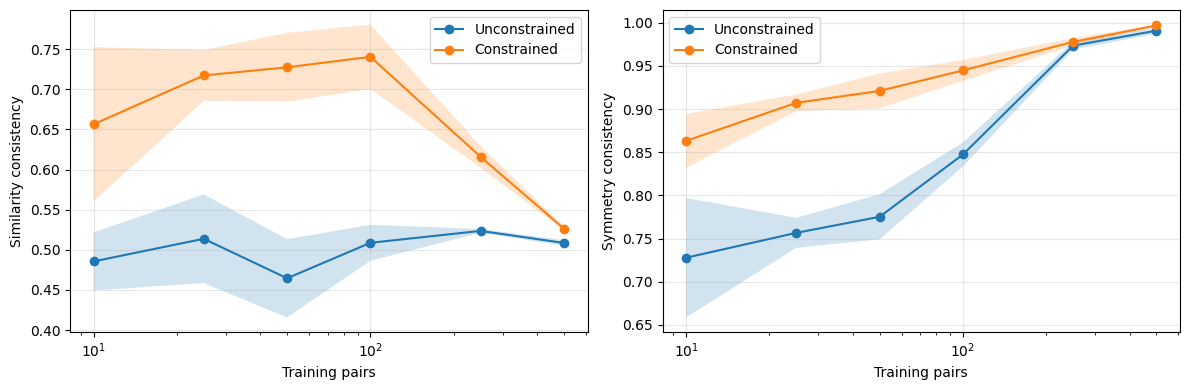

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, key, title in [
    (ax1, "sim", "Similarity consistency"),
    (ax2, "sym", "Symmetry consistency"),
]:
    for label, res in [("Unconstrained", results_u), ("Constrained", results_c)]:
        means = np.array([np.mean(res[n][key]) for n in train_sizes])
        sems  = np.array([np.std(res[n][key], ddof=1) / np.sqrt(n_trials) for n in train_sizes])
        line, = ax.plot(train_sizes, means, marker="o", label=label)
        ax.fill_between(train_sizes, means - sems, means + sems, alpha=0.2)
    ax.set_xlabel("Training pairs")
    ax.set_ylabel(title)
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The left panel shows similarity consistency: how often each model predicts "similar". Both models improve with more data. The right panel shows symmetry constraint satisfaction. The constrained model maintains much higher symmetry across all training sizes. With very little data, the constraint provides the strongest relative benefit: the unconstrained model has essentially random symmetry at 10 pairs, while the constrained model is already substantially more symmetric.

A natural next step is to see how `pysignet` handles more complex supervision, such as learning digit classifiers from indirect labels. See the [MNIST Addition notebook](MNIST%20Addition.ipynb).